#### Book Lengths in Characters, Words, and Tokens

In [1]:
import tiktoken
enc = tiktoken.get_encoding("cl100k_base")

In [2]:
import urllib.request

# 3 books download karo
books = {
    "Moby Dick":  "https://www.gutenberg.org/files/2701/2701-0.txt",
    "Frankenstein": "https://www.gutenberg.org/files/84/84-0.txt",
    "Alice in Wonderland": "https://www.gutenberg.org/files/11/11-0.txt"
}

book_texts = {}

for name, url in books.items():
    with urllib.request.urlopen(url) as f:
        book_texts[name] = f.read().decode("utf-8")
    print(f"Downloaded: {name} ({len(book_texts[name])} characters)")

Downloaded: Moby Dick (1219043 characters)
Downloaded: Frankenstein (419434 characters)
Downloaded: Alice in Wonderland (144696 characters)


In [3]:
import pandas as pd

results = []

for name, text in book_texts.items():
    char_count  = len(text)
    word_count  = len(text.split())
    token_count = len(enc.encode(text))
    
    results.append({
        "Book": name,
        "Characters": char_count,
        "Words": word_count,
        "Tokens": token_count
    })

df = pd.DataFrame(results)
print(df.to_string(index=False))

               Book  Characters  Words  Tokens
          Moby Dick     1219043 212814  307614
       Frankenstein      419434  75060   98003
Alice in Wonderland      144696  26543   36958


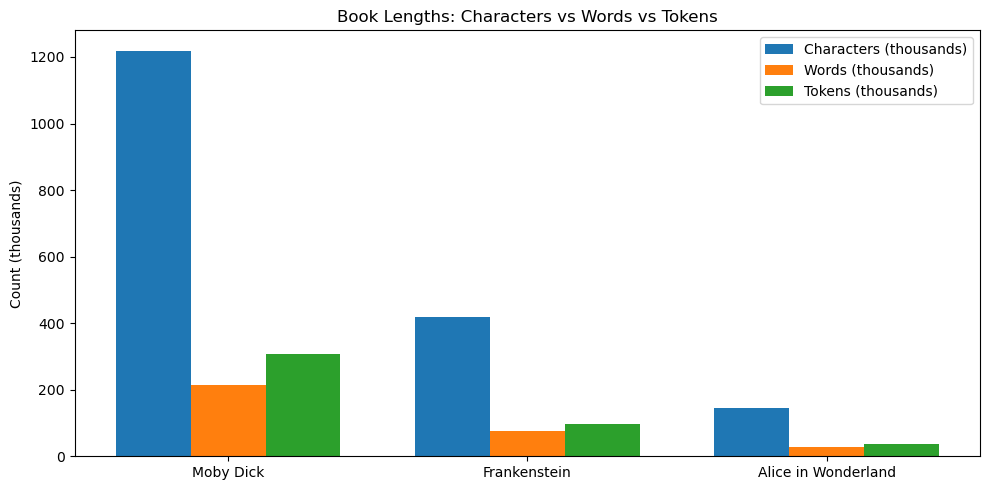

In [4]:
import matplotlib.pyplot as plt
import numpy as np

books_names = df["Book"].tolist()
x = np.arange(len(books_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - width, df["Characters"]/1000, width, label="Characters (thousands)")
ax.bar(x,         df["Words"]/1000,      width, label="Words (thousands)")
ax.bar(x + width, df["Tokens"]/1000,     width, label="Tokens (thousands)")

ax.set_xticks(x)
ax.set_xticklabels(books_names)
ax.set_ylabel("Count (thousands)")
ax.set_title("Book Lengths: Characters vs Words vs Tokens")
ax.legend()

plt.tight_layout()
plt.show()

In real books, the number of tokens is always greater than the number of words.

The ratio is typically around 1.3x to 1.4x
(i.e., 100 words ≈ 130–140 tokens).

This ratio is important because it helps in estimating LLM costs, since most models charge based on the number of tokens processed.